# Symmetry-aware encoding (Phases A, B & C)

**Phase A** — Co-design encoding + U(1) charge map.
**Phase B** — Robustness under label-preserving transforms (eval only).
**Phase C** — Full pipeline: semantic encoder → compat gate → U(1) `:hard` → optional **augmented training**; augmented **test** suite.

| Map | Encoder | `Q(x)` meaning |
|-----|---------|----------------|
| `bucket_C4` | `BasisEncoder(3)` | centered bucket sum |
| `sign_C4` | `SignIncrementEncoder` | net up − down |
| `upcount_C4` | `UpDownIncrementEncoder` | up-count (`q_label_mode=:round`) |

Re-run **§1** after pulling library changes.


In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.instantiate()

using MPSFast
using MPSFast.Encoders
using Random, Statistics, Printf
using Plots

function refresh_mpsfast_training!()
    pkg = pkgdir(MPSFast)
    src = joinpath(pkg, "src")
    for f in ("symmetry.jl", "u1_block_sparse.jl", "training.jl")
        Base.include(MPSFast, joinpath(src, f))
    end
    global train_mps! = MPSFast.train_mps!
    global cosine_lr = MPSFast.cosine_lr
end
refresh_mpsfast_training!()

D_max, η, ε_cut = 32, 5e-4, 1e-5
n_epochs, patience = 40, 6
seed_main = 7
compat_threshold_C = 0.15  # Phase C gate


  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
┌ Warning: Replacing docs for `MPSFast.SymmetryMode :: Union{}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast.U1Spec :: Union{}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast.NoSymmetry :: Union{}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast.symmetry_active :: Tuple{U1Spec}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast.u1_label_spec :: Tuple{Int64}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast.u1_path_centered_spec :: Tuple{Int64, Int64}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast.bounded_q_label :: Tuple{Real}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast.u1_path_sign_increme

0.15

## 1. Shared data & charge-map registry

Encoders are **label-agnostic**. C4 `q_label` sectors are fit from training data only inside `u1_path_empirical_from_probe` / `u1_path_empirical_spec`.


In [2]:
function synthetic_paths_labels(N, M; drift=0.15, σ=1.0, rng=Random.default_rng())
    paths  = Matrix{Float64}(undef, N, M)
    labels = Vector{Int}(undef, N)
    for i in 1:N
        y = rand(rng, 1:2)
        d = y == 1 ? drift : -drift
        paths[i, :] = cumsum(d .+ σ .* randn(rng, M))
        labels[i]   = y
    end
    return paths, labels
end

function random_walk_paths(N, M; drift=0.0, σ=1.0, rng=Random.default_rng())
    paths = Matrix{Float64}(undef, N, M)
    for i in 1:N
        paths[i, :] = cumsum(drift .+ σ .* randn(rng, M))
    end
    return paths
end

function make_bundle(kind::Symbol, enc::PathEncoder;
    N_train=1_500, N_test=400, M=15, n_classes=2, rng=Random.default_rng())
    if kind == :drift
        train_paths, train_labels = synthetic_paths_labels(N_train, M; rng=rng)
        test_paths,  test_labels  = synthetic_paths_labels(N_test,  M; rng=rng)
    elseif kind == :neutral
        train_paths = random_walk_paths(N_train, M; rng=rng)
        test_paths  = random_walk_paths(N_test,  M; rng=rng)
        train_labels = rand(rng, 1:n_classes, N_train)
        test_labels  = rand(rng, 1:n_classes, N_test)
    elseif kind == :flux_nearest
        train_paths = random_walk_paths(N_train, M; rng=rng)
        test_paths  = random_walk_paths(N_test,  M; rng=rng)
        enc isa BasisEncoder && fit_grid!(enc, train_paths)
        d0 = site_dim(enc)
        probe0 = enc isa SignIncrementEncoder ? u1_path_sign_increment_spec(d0, n_classes) :
            (enc isa UpDownIncrementEncoder ? u1_path_upcount_spec(d0, n_classes) :
                u1_path_centered_spec(d0, n_classes))
        xi_tr0 = encode_paths(enc, train_paths)
        xi_te0 = encode_paths(enc, test_paths)
        train_labels = [flux_nearest_class(xi_tr0[i, :], probe0, n_classes) for i in 1:N_train]
        test_labels  = [flux_nearest_class(xi_te0[i, :], probe0, n_classes) for i in 1:N_test]
    else
        error("kind must be :drift, :neutral, or :flux_nearest")
    end
    enc isa BasisEncoder && fit_grid!(enc, train_paths)
    xi_train = encode_labeled_paths(enc, train_paths, train_labels; n_classes=n_classes)
    xi_test  = encode_labeled_paths(enc, test_paths,  test_labels;  n_classes=n_classes)
    return (; kind, enc, train_paths, train_labels, test_paths, test_labels,
            xi_train, xi_test, Ml=classification_chain_length(enc, M),
            d=site_dim(enc), n_classes, M)
end

function build_spec_bucket(d, nc, xi)
    u1_path_empirical_spec(d, nc, xi)
end

function build_spec_sign(d, nc, xi)
    probe = u1_path_sign_increment_spec(d, nc)
    u1_path_empirical_from_probe(probe, xi, nc; q_label_mode=:round)
end

function build_spec_upcount(d, nc, xi)
    probe = u1_path_upcount_spec(d, nc)
    u1_path_empirical_from_probe(probe, xi, nc; q_label_mode=:round)
end

const CHARGE_MAPS = [
    (; name="bucket_C4",  enc=BasisEncoder(3),           build=build_spec_bucket),
    (; name="sign_C4",    enc=SignIncrementEncoder(),    build=build_spec_sign),
    (; name="upcount_C4", enc=UpDownIncrementEncoder(),  build=build_spec_upcount),
]


const _pct(x) = 100 * x

function dataset_rng(kind::Symbol, cm_name::String)
    base = Dict(:drift => 101, :neutral => 202, :flux_nearest => 303)
    return MersenneTwister(get(base, kind, 999) + hash(cm_name) % 1000)
end

DATASETS = [:drift, :neutral, :flux_nearest]
rng_setup = MersenneTwister(42)


MersenneTwister(42)

## 2. Phase A — compatibility diagnostics (no training)

Does a **semantic** charge map raise `compat` on drift where bucket-C4 fails?


In [3]:
println(@sprintf("%-14s %-12s %8s %8s", "dataset", "charge_map", "compat", "|ΔQ|"))
println("-" ^ 48)

for kind in DATASETS
    for cm in CHARGE_MAPS
        data = make_bundle(kind, cm.enc; rng=dataset_rng(kind, cm.name))
        spec = cm.build(data.d, data.n_classes, data.xi_train)
        compat = sector_compatibility_rate(data.xi_train, spec)
        Qs = path_charges(data.xi_train, spec)
        mean_abs_Q = mean(abs.(Qs))
        @printf "%-14s %-12s %7.3f %8.2f\n" string(kind) cm.name compat mean_abs_Q
    end
end


dataset        charge_map     compat     |ΔQ|
------------------------------------------------
drift          bucket_C4      0.044     8.78
drift          sign_C4        0.000     3.43
drift          upcount_C4     0.190     7.61
neutral        bucket_C4      0.055     7.83
neutral        sign_C4        0.000     3.08
neutral        upcount_C4     0.203     7.51
flux_nearest   bucket_C4      0.097     7.47
flux_nearest   sign_C4        0.297     3.16
flux_nearest   upcount_C4     0.188     7.58


### Phase A — training panel (drift, `seed_main=7`)

Baseline dense MPS vs Phase-0 U(1) soft masking with C4 empirical spec per charge map.


In [4]:
function train_classifier(; data, spec, seed, use_u1::Bool)
    rng = MersenneTwister(seed)
    nc, d, Ml = data.n_classes, data.d, data.Ml
    spec_eff = use_u1 ? spec : NoSymmetry
    if use_u1
        mps = init_mps_classification_u1(Ml, d, nc, D_max, spec_eff; rng=rng)
    else
        mps = init_mps_classification(Ml, d, nc, D_max; rng=rng)
    end
    train_mps!(mps, data.xi_train, n_epochs, η, D_max, ε_cut;
        verbose=false, lr_schedule=cosine_lr,
        val_data=data.xi_test, val_samples=300, patience=patience,
        u1_spec=spec_eff, u1_conservation=use_u1 ? :soft : :none,
        u1_soft_strength=0.9, n_classes=nc, d_path=d)
    acc = classification_accuracy(mps, data.xi_test, nc)
    _, _, forbid = u1_forbidden_mass(mps, spec_eff; n_classes=nc, d_path=d)
    return (; acc, forbid)
end

println(@sprintf("%-12s %-10s %7s %7s %10s", "charge", "model", "test%", "compat", "forbid"))
for cm in CHARGE_MAPS
    data = make_bundle(:drift, cm.enc; rng=MersenneTwister(42))
    spec = cm.build(data.d, data.n_classes, data.xi_train)
    compat = sector_compatibility_rate(data.xi_train, spec)
    for (tag, u1) in (("baseline", false), ("U1_soft", true))
        r = train_classifier(; data, spec, seed=seed_main, use_u1=u1)
        @printf "%-12s %-10s %6.1f%% %7.3f %10.4f\n" cm.name tag _pct(r.acc) compat r.forbid
    end
end


charge       model        test%  compat     forbid
bucket_C4    baseline     67.8%   0.059     0.0000
bucket_C4    U1_soft      64.5%   0.059     1.0000
sign_C4      baseline     54.8%   0.000     0.0000
sign_C4      U1_soft      55.0%   0.000     1.0000
upcount_C4   baseline     47.8%   0.188     0.0000
upcount_C4   U1_soft      52.2%   0.188     1.0000


## 3. Phase B — equivariance & robustness

**T_rescale**: multiply paths by `α ∈ {0.5, 2.0}` — sign/upcount encodings are **exactly invariant**; bucket encoding changes.

**T_vol**: regenerate test set with `σ_test = 2σ_train` (same labels) — increments can flip sign → nontrivial shift.

We report `acc_clean`, `acc_T`, and gap `Δ`.


In [5]:
rescale_paths(paths, α) = α .* paths

function regenerate_drift(paths, labels; σ, drift=0.15, rng)
    N, M = size(paths)
    out = Matrix{Float64}(undef, N, M)
    for i in 1:N
        y = labels[i]
        d = y == 1 ? drift : -drift
        out[i, :] = cumsum(d .+ σ .* randn(rng, M))
    end
    return out
end

function eval_on_paths(mps, enc, paths, labels, spec, nc)
    xi = encode_labeled_paths(enc, paths, labels; n_classes=nc)
    return classification_accuracy(mps, xi, nc)
end

function encoding_invariant_under_rescale(enc, paths, alphas=(0.5, 2.0))
    xi0 = encode_paths(enc, paths[1:min(20, size(paths,1)), :])
    for α in alphas
        pr = rescale_paths(paths[1:size(xi0,1), :], α)
        xiα = encode_paths(enc, pr)
        xiα == xi0 || return false
    end
    return true
end

println("Encoding invariance under path rescale (first 20 test paths):")
for cm in CHARGE_MAPS
    data = make_bundle(:drift, cm.enc; rng=MersenneTwister(42))
    inv = encoding_invariant_under_rescale(cm.enc, data.test_paths)
    println("  ", cm.name, "  →  ", inv ? "invariant" : "NOT invariant")
end


Encoding invariance under path rescale (first 20 test paths):
  bucket_C4  →  NOT invariant
  sign_C4  →  invariant
  upcount_C4  →  invariant


In [6]:
# Train once per (encoder, model); evaluate clean + augmented tests
σ_train, σ_test = 1.0, 2.0
alphas = (0.5, 2.0)

results_B = NamedTuple[]

for cm in CHARGE_MAPS
    data = make_bundle(:drift, cm.enc; rng=MersenneTwister(42))
    spec = cm.build(data.d, data.n_classes, data.xi_train)
    for (tag, use_u1) in (("baseline", false), ("U1_soft", true))
        rng = MersenneTwister(seed_main + hash(cm.name * tag) % 10_000)
        nc, d, Ml = data.n_classes, data.d, data.Ml
        spec_eff = use_u1 ? spec : NoSymmetry
        mps = use_u1 ?
            init_mps_classification_u1(Ml, d, nc, D_max, spec_eff; rng=rng) :
            init_mps_classification(Ml, d, nc, D_max; rng=rng)
        train_mps!(mps, data.xi_train, n_epochs, η, D_max, ε_cut;
            verbose=false, lr_schedule=cosine_lr,
            val_data=data.xi_test, val_samples=300, patience=patience,
            u1_spec=spec_eff, u1_conservation=use_u1 ? :soft : :none,
            u1_soft_strength=0.9, n_classes=nc, d_path=d)
        acc_clean = classification_accuracy(mps, data.xi_test, nc)
        # rescale: worst α (min acc over alphas)
        acc_res = [eval_on_paths(mps, cm.enc, rescale_paths(data.test_paths, α),
            data.test_labels, spec_eff, nc) for α in alphas]
        acc_res_min = minimum(acc_res)
        # volatility shift
        paths_vol = regenerate_drift(data.test_paths, data.test_labels;
            σ=σ_test, rng=MersenneTwister(99))
        acc_vol = eval_on_paths(mps, cm.enc, paths_vol, data.test_labels, spec_eff, nc)
        push!(results_B, (; charge=cm.name, model=tag, acc_clean, acc_rescale=acc_res_min,
            acc_vol, Δ_rescale=acc_clean - acc_res_min, Δ_vol=acc_clean - acc_vol))
    end
end

println(@sprintf("%-12s %-10s %7s %7s %7s %7s %7s", "charge", "model",
    "clean%", "res%", "vol%", "Δ_res", "Δ_vol"))
for r in results_B
    @printf("%-12s %-10s %6.1f%% %6.1f%% %6.1f%% %6.1f%% %6.1f%%\n",
        r.charge, r.model, _pct(r.acc_clean), _pct(r.acc_rescale), _pct(r.acc_vol),
        _pct(r.Δ_rescale), _pct(r.Δ_vol))
end


charge       model       clean%    res%    vol%   Δ_res   Δ_vol
bucket_C4    baseline     66.8%   65.0%   60.8%    1.7%    6.0%
bucket_C4    U1_soft      62.5%   57.2%   58.0%    5.2%    4.5%
sign_C4      baseline     51.7%   51.7%   51.5%    0.0%    0.2%
sign_C4      U1_soft      47.2%   47.2%   52.0%    0.0%   -4.8%
upcount_C4   baseline     51.7%   51.7%   53.5%    0.0%   -1.8%
upcount_C4   U1_soft      56.2%   56.2%   55.8%    0.0%    0.5%


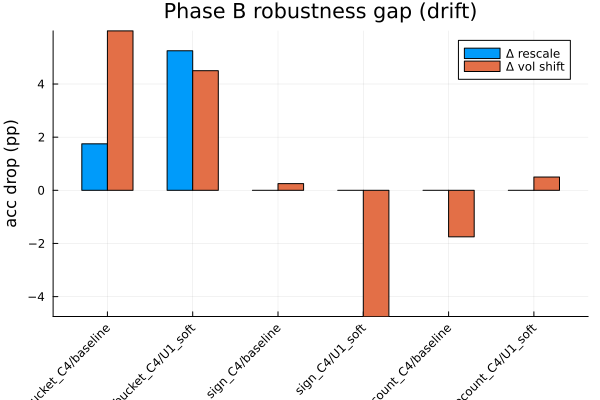

In [7]:
# Visualise robustness gaps (Phase B)
charges = [r.charge for r in results_B]
models  = [r.model for r in results_B]
x = 1:length(results_B)
bar(x .- 0.15, [_pct(r.Δ_rescale) for r in results_B]; label="Δ rescale", bar_width=0.3)
bar!(x .+ 0.15, [_pct(r.Δ_vol) for r in results_B]; label="Δ vol shift", bar_width=0.3)
plot!(xticks=(x, [r.charge * "/" * r.model for r in results_B]),
    xrotation=45, ylabel="acc drop (pp)", legend=:topright,
    title="Phase B robustness gap (drift)")


## 4. Phase C — symmetry-aware pipeline + augmented train/test

Pipeline per run:
1. Label-agnostic encoder Φ(x)
2. C4 empirical spec (train labels only for `q_label`)
3. **Compat gate** — skip U(1) when `compat < compat_threshold_C`
4. U(1) `:hard` (not soft at low compat)
5. Optional **augmented training** (rescale + vol resample, same labels)

Test suite: **clean**, **rescale** (worst of α∈{0.5,2}), **vol** (σ_test=2).


In [8]:
# ── Phase C helpers ──────────────────────────────────────────────────────────
rescale_paths(paths, α) = α .* paths

function regenerate_drift_labeled(labels::Vector{Int}, M::Int;
    σ=1.0, drift=0.15, rng=Random.default_rng())
    N = length(labels)
    paths = Matrix{Float64}(undef, N, M)
    for i in 1:N
        y = labels[i]
        d = y == 1 ? drift : -drift
        paths[i, :] = cumsum(d .+ σ .* randn(rng, M))
    end
    return paths
end

function augment_train_bundle(data;
    rescale_alphas=(0.5, 2.0), vol_sigmas=(1.0, 2.0), rng=Random.default_rng())
    enc, nc, M = data.enc, data.n_classes, data.M
    paths, labels = data.train_paths, data.train_labels
    parts_p, parts_y = Matrix{Float64}[], Vector{Int}[]
    push!(parts_p, paths); push!(parts_y, labels)
    for α in rescale_alphas
        push!(parts_p, rescale_paths(paths, α)); push!(parts_y, labels)
    end
    for σ in vol_sigmas
        push!(parts_p, regenerate_drift_labeled(labels, M; σ=σ, rng=rng))
        push!(parts_y, labels)
    end
    train_paths = vcat(parts_p...)
    train_labels = vcat(parts_y...)
    xi_train = encode_labeled_paths(enc, train_paths, train_labels; n_classes=nc)
    return (; kind=data.kind, enc=data.enc, train_paths, train_labels,
        test_paths=data.test_paths, test_labels=data.test_labels,
        xi_train, xi_test=data.xi_test, Ml=data.Ml, d=data.d,
        n_classes=data.n_classes, M=data.M, augmented=true)
end

struct PhaseCPlan
    use_symmetry::Bool
    spec::U1Spec
    conservation::Symbol
    reason::String
end

function resolve_phase_c_plan(spec::U1Spec, xi_train;
    compat_threshold=compat_threshold_C, gate::Bool=true)
    compat = sector_compatibility_rate(xi_train, spec)
    if !gate
        return PhaseCPlan(true, spec, :hard, "U1 hard (gate off)")
    end
    if compat < compat_threshold
        return PhaseCPlan(false, NoSymmetry, :none,
            "compat=$(round(compat; digits=3)) < $(compat_threshold)")
    end
    return PhaseCPlan(true, spec, :hard,
        "compat=$(round(compat; digits=3)) ≥ $(compat_threshold)")
end

function train_phase_c(data, plan::PhaseCPlan; seed=seed_main)
    rng = MersenneTwister(seed)
    nc, d, Ml = data.n_classes, data.d, data.Ml
    spec = plan.use_symmetry ? plan.spec : NoSymmetry
    mps = plan.use_symmetry ?
        init_mps_classification_u1(Ml, d, nc, D_max, spec; rng=rng) :
        init_mps_classification(Ml, d, nc, D_max; rng=rng)
    train_mps!(mps, data.xi_train, n_epochs, η, D_max, ε_cut;
        verbose=false, lr_schedule=cosine_lr,
        val_data=data.xi_test, val_samples=300, patience=patience,
        u1_spec=spec, u1_conservation=plan.conservation,
        u1_soft_strength=0.9, n_classes=nc, d_path=d)
    return mps
end

function eval_accuracy(mps, enc, paths, labels, nc)
    xi = encode_labeled_paths(enc, paths, labels; n_classes=nc)
    classification_accuracy(mps, xi, nc)
end

function eval_suite(mps, data; σ_test=2.0, alphas=(0.5, 2.0), rng=MersenneTwister(77))
    enc, nc = data.enc, data.n_classes
    clean = eval_accuracy(mps, enc, data.test_paths, data.test_labels, nc)
    res = [eval_accuracy(mps, enc, rescale_paths(data.test_paths, α),
        data.test_labels, nc) for α in alphas]
    paths_vol = regenerate_drift_labeled(data.test_labels, data.M; σ=σ_test, rng=rng)
    vol = eval_accuracy(mps, enc, paths_vol, data.test_labels, nc)
    res_min, res_max = extrema(res)
    return (; clean, res_min, res_max, vol,
        Δ_rescale=clean - res_min, Δ_vol=clean - vol)
end

const PHASE_C_MODES = [
    (; tag="baseline",   use_u1=false, gate=false, conservation=:none, augment=false),
    (; tag="u1_soft",    use_u1=true,  gate=false, conservation=:soft, augment=false),
    (; tag="gated_hard", use_u1=true,  gate=true,  conservation=:hard, augment=false),
    (; tag="gated_aug",  use_u1=true,  gate=true,  conservation=:hard, augment=true),
]

function run_phase_c(cm; mode, data_kind=:drift, seed=seed_main)
    data = make_bundle(data_kind, cm.enc; rng=MersenneTwister(42))
    if mode.augment
        data = augment_train_bundle(data; rng=MersenneTwister(88))
    end
    spec = cm.build(data.d, data.n_classes, data.xi_train)
    compat = sector_compatibility_rate(data.xi_train, spec)
    plan = if !mode.use_u1
        PhaseCPlan(false, NoSymmetry, :none, "baseline")
    elseif mode.gate
        resolve_phase_c_plan(spec, data.xi_train)
    else
        PhaseCPlan(true, spec, mode.conservation, "U1 $(mode.conservation) (no gate)")
    end
    mps = train_phase_c(data, plan; seed=seed)
    ev = eval_suite(mps, data)
    aug_tag = mode.augment ? " +train_aug" : ""
    return (; charge=cm.name, mode=mode.tag, compat, plan=plan.reason * aug_tag, ev=ev)
end



run_phase_c (generic function with 1 method)

In [9]:
# Phase C.0 — upcount with q_label_mode=:round (fix from Phase A)
println("upcount compat after :round q_label (drift):")
data_u = make_bundle(:drift, UpDownIncrementEncoder(); rng=MersenneTwister(42))
for mode in (:bounded, :round)
    probe = u1_path_upcount_spec(data_u.d, data_u.n_classes)
    spec = u1_path_empirical_from_probe(probe, data_u.xi_train, data_u.n_classes;
        q_label_mode=mode)
    c = sector_compatibility_rate(data_u.xi_train, spec)
    println("  ", mode, "  compat=", round(c; digits=3))
end



upcount compat after :round q_label (drift):
  bounded  compat=0.002
  round  compat=0.188


In [10]:
# Phase C.1 — pipeline panel (drift; sign + bucket × 4 modes)
PHASE_C_FOCUS = [CHARGE_MAPS[2], CHARGE_MAPS[1]]  # sign, bucket

results_C = Any[]
for cm in PHASE_C_FOCUS
    for mode in PHASE_C_MODES
        push!(results_C, run_phase_c(cm; mode=mode))
    end
end

println(@sprintf("%-12s %-12s %7s %10s %7s %7s %7s %7s %7s",
    "charge", "mode", "compat", "plan", "clean%", "res%", "vol%", "Δ_res", "Δ_vol"))
for r in results_C
    @printf("%-12s %-12s %7.3f %-10s %6.1f%% %6.1f%% %6.1f%% %6.1f%% %6.1f%%\n",
        r.charge, r.mode, r.compat, r.plan,
        _pct(r.ev.clean), _pct(r.ev.res_min), _pct(r.ev.vol),
        _pct(r.ev.Δ_rescale), _pct(r.ev.Δ_vol))
end



charge       mode          compat       plan  clean%    res%    vol%   Δ_res   Δ_vol
sign_C4      baseline       0.000 baseline     53.5%   53.5%   57.0%    0.0%   -3.5%
sign_C4      u1_soft        0.000 U1 soft (no gate)   54.0%   54.0%   52.8%    0.0%    1.3%
sign_C4      gated_hard     0.000 compat=0.0 < 0.15   55.0%   55.0%   55.8%    0.0%   -0.7%
sign_C4      gated_aug      0.095 compat=0.095 < 0.15 +train_aug   51.7%   51.7%   57.2%    0.0%   -5.5%
bucket_C4    baseline       0.059 baseline     66.2%   56.5%   54.8%    9.8%   11.5%
bucket_C4    u1_soft        0.059 U1 soft (no gate)   67.2%   58.0%   53.0%    9.3%   14.2%
bucket_C4    gated_hard     0.059 compat=0.059 < 0.15   66.0%   64.8%   57.0%    1.3%    9.0%
bucket_C4    gated_aug      0.047 compat=0.047 < 0.15 +train_aug   62.7%   63.7%   53.2%   -1.0%    9.5%


In [11]:
# Phase C.2 — augmented test matrix (sign_C4, gated modes)
function test_conditions(data; σ_test=2.0, alphas=(0.5, 2.0), rng=MersenneTwister(77))
    conds = NamedTuple[]
    push!(conds, (; name="clean", paths=data.test_paths))
    for α in alphas
        push!(conds, (; name="rescale_$(α)", paths=rescale_paths(data.test_paths, α)))
    end
    push!(conds, (; name="vol_$(σ_test)",
        paths=regenerate_drift_labeled(data.test_labels, data.M; σ=σ_test, rng=rng)))
    return conds
end

cm = CHARGE_MAPS[2]  # sign_C4
data_base = make_bundle(:drift, cm.enc; rng=MersenneTwister(42))
conds = test_conditions(data_base)

aug_matrix = Dict{String, Dict{String, Float64}}()
for mode in (PHASE_C_MODES[1], PHASE_C_MODES[3], PHASE_C_MODES[4])  # baseline, gated_hard, gated_aug
    d_run = mode.augment ? augment_train_bundle(data_base; rng=MersenneTwister(88)) : data_base
    spec = cm.build(d_run.d, d_run.n_classes, d_run.xi_train)
    plan = !mode.use_u1 ? PhaseCPlan(false, NoSymmetry, :none, "baseline") :
        (mode.gate ? resolve_phase_c_plan(spec, d_run.xi_train) :
            PhaseCPlan(true, spec, mode.conservation, mode.tag))
    mps = train_phase_c(d_run, plan; seed=seed_main)
    aug_matrix[mode.tag] = Dict{String, Float64}()
    for c in conds
        acc = eval_accuracy(mps, cm.enc, c.paths, data_base.test_labels, data_base.n_classes)
        aug_matrix[mode.tag][c.name] = acc
    end
end

println("\nAugmented test matrix (sign_C4, drift):")
println(@sprintf("%-14s %7s %7s %7s %7s", "mode", "clean", "r0.5", "r2.0", "vol2"))
for (tag, row) in aug_matrix
    @printf("%-14s %6.1f%% %6.1f%% %6.1f%% %6.1f%%\n", tag,
        _pct(get(row, "clean", 0.0)), _pct(get(row, "rescale_0.5", 0.0)),
        _pct(get(row, "rescale_2.0", 0.0)), _pct(get(row, "vol_2.0", 0.0)))
end




Augmented test matrix (sign_C4, drift):
mode             clean    r0.5    r2.0    vol2
gated_hard       53.5%   53.5%   53.5%   56.0%
gated_aug        51.2%   51.2%   51.2%   54.2%
baseline         54.2%   54.2%   54.2%   56.5%


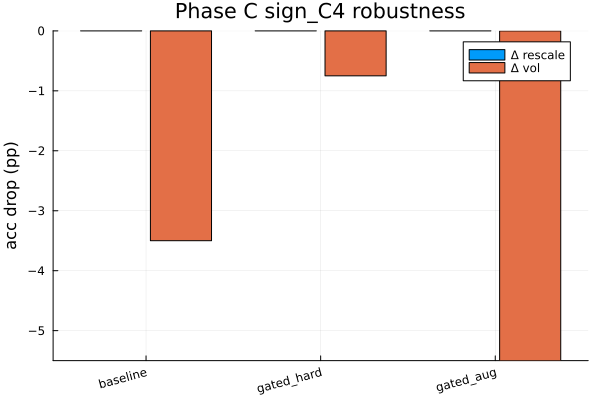

In [12]:
# Phase C.3 — robustness comparison (gated_hard vs gated_aug vs baseline)
tags = ["baseline", "gated_hard", "gated_aug"]
sub = [r for r in results_C if r.charge == "sign_C4" && r.mode in tags]
if isempty(sub)
  sub = [r for r in results_C if r.mode in tags]
end
x = 1:length(sub)
bar(x .- 0.2, [_pct(r.ev.Δ_rescale) for r in sub]; label="Δ rescale", bar_width=0.35)
bar!(x .+ 0.2, [_pct(r.ev.Δ_vol) for r in sub]; label="Δ vol", bar_width=0.35)
plot!(xticks=(x, [r.mode for r in sub]), xrotation=15,
    ylabel="acc drop (pp)", title="Phase C sign_C4 robustness",
    legend=:topright)

